# Install & Import Library

In [ ]:
!pip install optuna gensim spacy tensorflow scikit-learn

import numpy as np
import pandas as pd
import spacy
from gensim.models import KeyedVectors
import optuna
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.8 MB/s eta 0:00:00


# Load spaCy Tokenizer (Indonesia)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nlp = spacy.blank("id")  # tokenizer-only, paling cepat

def spacy_tokenize(text):
    return [t.text for t in nlp(text)]


# Load Dataset + Split Train/Val/Test :

In [ ]:
import os
file_path = "../../Dataset/Pre-Processed Dataset/Before_remove@and#/combined_dataset.csv"
if not os.path.exists(file_path):
    file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load FastText Embedding

In [ ]:
import os
fasttext_path = "../../cc.id.300.vec"
if not os.path.exists(fasttext_path):
    fasttext_path = "/content/drive/MyDrive/DistilBERT-7-Mei/cc.id.300.vec"

w2v = KeyedVectors.load_word2vec_format(fasttext_path, binary=False)

embedding_dim = 300


# Build Vocabulary + Convert to Sequence (Menggunakan spaCY)

In [ ]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 reserved for PAD

    for txt in texts:
        for tok in spacy_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert text to indexed sequences:

In [ ]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = spacy_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec = convert_dataset(X_val)
X_test_vec = convert_dataset(X_test)


# Build Bi-GRU Model (with ReLU + Dropout)

In [ ]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Optuna Objective No  K-Fold

In [ ]:
# Optuna Objective TANPA K-Fold
def objective(trial):

    h_units = trial.suggest_int("h_units", 32, 128)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    # Build model
    model = build_model(h_units, dropout_rate, lr)

    # Train model
    model.fit(
        X_train_vec, y_train,
        validation_data=(X_val_vec, y_val),
        epochs=5,
        batch_size=32,
        verbose=0
    )

    # Predict on validation
    preds = (model.predict(X_val_vec) > 0.5).astype("int32")

    # Use F1-score for optimization
    f1 = f1_score(y_val, preds)

    return f1


# Jalankan Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best = study.best_params
best


[I 2025-11-26 07:18:53,525] A new study created in memory with name: no-name-e6f9b57e-ebe6-4839-8055-fd59dde5a656


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


[I 2025-11-26 07:19:06,819] Trial 0 finished with value: 0.8542713567839196 and parameters: {'h_units': 57, 'dropout': 0.12834704838872324, 'lr': 0.0005907607908183747}. Best is trial 0 with value: 0.8542713567839196.


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


[I 2025-11-26 07:19:11,701] Trial 1 finished with value: 0.60431654676259 and parameters: {'h_units': 100, 'dropout': 0.20115417636493282, 'lr': 0.00018960717398344376}. Best is trial 0 with value: 0.8542713567839196.


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


[I 2025-11-26 07:23:30,940] Trial 48 finished with value: 0.8325358851674641 and parameters: {'h_units': 86, 'dropout': 0.4824623594680838, 'lr': 0.002069126346122229}. Best is trial 28 with value: 0.8852459016393442.


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


[I 2025-11-26 07:23:36,079] Trial 49 finished with value: 0.8367346938775511 and parameters: {'h_units': 36, 'dropout': 0.19320868994284962, 'lr': 0.0013963775333423853}. Best is trial 28 with value: 0.8852459016393442.


{'h_units': 42, 'dropout': 0.24787681501663505, 'lr': 0.0016502625661843147}

# Final Training on Train + Val

In [ ]:
best_h = best["h_units"]
best_drop = best["dropout"]
best_lr = best["lr"]

final_model = build_model(best_h, best_drop, best_lr)

X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

final_model.fit(
    X_final, y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5539 - loss: 0.6750
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7996 - loss: 0.4749
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8695 - loss: 0.3224
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8896 - loss: 0.2543
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9081 - loss: 0.2164
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9151 - loss: 0.2098
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9334 - loss: 0.1713
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9245 - loss: 0.1770
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9500 - loss: 0.1380
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9423 - loss: 0.1461


# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

         0.0     0.8708    0.9167    0.8932       228
         1.0     0.8908    0.8333    0.8611       186

    accuracy                         0.8792       414
   macro avg     0.8808    0.8750    0.8771       414
weighted avg     0.8798    0.8792    0.8788       414



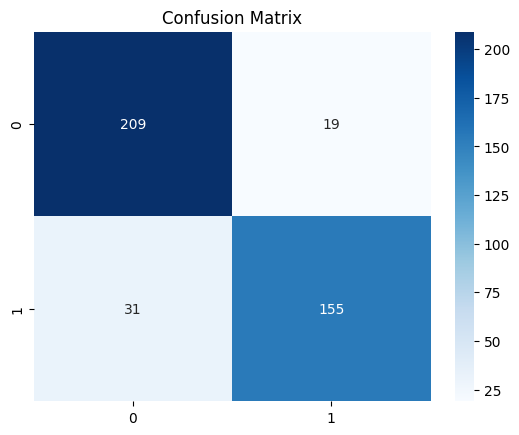

Macro F1: 0.8771367521367521


In [ ]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


# Save Experiment Configuration

In [ ]:
import json
from pprint import pprint

experiment_config = {
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "bigru",
    "best_params": best,
    "embedding_dim": embedding_dim
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))



Experiment Configuration:
{'best_params': {'dropout': 0.24787681501663505,
                 'h_units': 42,
                 'lr': 0.0016502625661843147},
 'embedding': 'fasttext',
 'embedding_dim': 300,
 'model': 'bigru',
 'tokenizer': 'spacy'}

JSON Format:
{
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "bigru",
    "best_params": {
        "h_units": 42,
        "dropout": 0.24787681501663505,
        "lr": 0.0016502625661843147
    },
    "embedding_dim": 300
}
